In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import glob as glob
import os
from importlib import reload
%matplotlib inline
import sys
sys.path.append("modules")
import bedgraph_tools as bgt
import peak_tools as pkt
from collections import defaultdict
import pyBigWig as pw
from matplotlib_venn import venn2
import pysam
from itertools import groupby
from Bio import motifs
import logomaker
from Bio import Align
from Bio.Seq import Seq
%config InlineBackend.figure_format='retina'
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
from scipy import stats
from scipy.interpolate import interp1d
import matplotlib.colors as mcolors
import upsetplot
from scipy.ndimage import uniform_filter
aligner = Align.PairwiseAligner()


In [2]:
def prepare_for_QC_plot(df, tf):
    br = pd.concat([pd.read_csv(x, index_col=0) for x in df.loc[:, 'Bad_Regs'].values], axis=0)
    # df = pd.concat([df, br], axis=1)
    if tf == 'SMAD':
        t_c = pd.DataFrame(br.reset_index().loc[:, 'index']\
                           .apply(lambda x: ['Treat', 'cornflowerblue'] if 'BMP' in x else ['Control', 'gray']).to_dict()).T
    elif tf == 'other':
        t_c = pd.DataFrame(br.reset_index().loc[:, 'index']\
                           .apply(lambda x: ['Treat', 'cornflowerblue'] if 'lbd' in x.lower() else ['Control', 'gray']).to_dict()).T
    else:
        t_c = pd.DataFrame(br.reset_index().loc[:, 'index']\
                           .apply(lambda x: ['Treat', 'cornflowerblue'] if 'lig' in x else ['Control', 'gray']).to_dict()).T
    t_c.index = br.index
    t_c.columns = ['Treat', 'Color']
    br = pd.concat([br, t_c], axis=1)
    br = pd.concat([br, df.loc[:,['RawBG', 'Read1BG']]], axis=1)
    br.loc[:, 'Sample'] = ['_'.join(x.split('_')[:-3]) for x in br.index]
    return br


def draw_ecdf(data, reads_thresh, ax, c):
    
    draw = data.filter(pl.col('Value')==reads_thresh)['distance'].drop_nulls()
    if draw.shape[0]>100:
        ax.ecdf(draw, label=reads_thresh, c=c)

def load_bedgraph(path):
    """
    Load a bedgraph file into a Polars DataFrame.

    Args:
        path (str): Path to the bedgraph file.

    Returns:
        pl.DataFrame: A Polars DataFrame with the bedgraph data.
    """
    return pl.read_csv(
        path,
        separator="\t",
        has_header=False,
        new_columns=["Chromosome", "Start", "End", "Value"],
    )


def plot_QC(df, analyzed, save=False, save_path=''):

    bins_val = [20,100,500,1000,2000,10000]
    ecdf_palette = sns.color_palette('Blues', n_colors=10)

    fig = plt.figure(figsize=(12,3), dpi=200)
    subf = fig.subfigures(1,3, width_ratios=[1,2,2])
    coverage_ax = subf[1].subplots(1)
    bll_ax, bins_ax = subf[0].subplots(2,1) 
    # bins_ax = subf[2].subplots(1)
    dist_ax = subf[2].subplots(2,1, sharex=True)

    bins_d = dict()
    for index,_,_,label,color,pathi, pathr1, sample in df.reset_index().values:


        loaded_clean = load_bedgraph(pathi).pipe(bgt.expand_data).pipe(bgt.clean_bg, mask)
        loaded_r1 = load_bedgraph(pathr1).pipe(bgt.expand_data).pipe(bgt.clean_bg, mask)

        dat = bgt.calc_frac_cov(loaded_clean, "Value")
        coverage_ax.plot(dat['Value'], dat['fraction'], label=label, c=color )

        calc = []
        for i in bins_val:
            treat = bgt.divide_bins(bgt.normalize_to_rpm(loaded_r1, 'Value'), i).group_by(["Chromosome", "bin_start", "bin_end"]).agg(
                    pl.col("Value").sum().alias("Mean_per_bin"))
            calc.append(treat['Mean_per_bin'].mean())

        distances = bgt.calculate_inter_read_distances(loaded_r1)


        if label == 'Treat':
            nax = dist_ax[0]
        else:
            nax = dist_ax[1]
        draw_ecdf(distances, 1, nax, c=ecdf_palette[0])
        draw_ecdf(distances, 2, nax, c=ecdf_palette[1])
        draw_ecdf(distances, 3, nax, c=ecdf_palette[2])
        draw_ecdf(distances, 4, nax, c=ecdf_palette[3])
        draw_ecdf(distances, 5, nax, c=ecdf_palette[4])
        draw_ecdf(distances, 6, nax, c=ecdf_palette[5])
        draw_ecdf(distances, 7, nax, c=ecdf_palette[6])
        draw_ecdf(distances, 8, nax, c=ecdf_palette[7])
        draw_ecdf(distances, 9, nax, c=ecdf_palette[8])
        draw_ecdf(distances, 10, nax, c=ecdf_palette[9])

        nax.set_xscale('log')
        nax.set_ylabel('ECDF')
        nax.axvline(100, c='k', ls=':', label='100 bp')

        bins_d[index] = calc
    coverage_ax.set_yscale('log')

    coverage_ax.legend()
    coverage_ax.set_xlim([1, 100])
    coverage_ax.set_ylim([1e-7,1])
    coverage_ax.set_xlabel('Coverage >=')
    coverage_ax.set_ylabel('Fraction of covered basepairs')



    bar_dat = df.iloc[:, [0,1,-1]].set_index('Sample').stack().reset_index()
    bar = sns.barplot(bar_dat, x='Sample', y=0, hue='level_1', ax=bll_ax, palette=['gray', 'cornflowerblue'], edgecolor='k', linewidth=1)
    sns.move_legend(bar, 'upper right', bbox_to_anchor=[.8,1.4])
    bll_ax.set_xticklabels(['no ligand', 'ligand'])
    bll_ax.set_ylabel('Fraction of reads')


    scat = pd.concat([df,pd.DataFrame(bins_d, index=bins_val).T], axis=1).loc[:, 'Sample':].set_index('Sample').stack().reset_index()
    scat = scat.groupby(['Sample', 'level_1']).mean().reset_index()
    sns.scatterplot(data=scat, x='level_1', y=0, hue="Sample",ax=bins_ax, palette=['cornflowerblue', 'gray'])
    bins_ax.set_xlabel('Bin width')
    bins_ax.set_ylabel('Mean of sum RPM per bin')
    bins_ax.legend()
    bins_ax.set_yscale('log')
    bins_ax.set_xscale('log')

    dist_ax[0].set_xscale('log')
    dist_ax[1].set_xscale('log')
    dist_ax[1].set_xlabel('Distance between \n neighbour reads (bp)')
    dist_ax[0].legend(bbox_to_anchor=[1.5,1])
    for axi in dist_ax:
        axi.set_ylabel('ECDF')
        axi.axvline(100, c='k', ls=':', label='100 bp')
    if save:
        fig.savefig(save_path)
        plt.close(fig)

def load_and_add_name_col(path, name):
    pp = pr.read_bed(path)
    pp = pp.insert(pd.Series(data = np.char.add(np.arange(len(pp)).astype(str), '_{}'.format(name)), name="Column"))
    return pp
def load_mot(path, mot_path):
    with open(mot_path) as handle:
        cosensus_mot = motifs.read(handle, "pfm-four-columns").consensus

        # Extract the motif sequences (not specifically used below)
    loaded_loc = pd.read_csv(os.path.join(path, 'fimo.tsv'), delimiter='\t').iloc[:-3,: ]#.loc[:, ['motif_id', 'sequence_name', 'start', 'stop', 'strand', 'matched_sequence']]
    seqs = loaded_loc.sort_values(by='score', ascending=False).loc[:, 'matched_sequence']
#     loaded_loc['strand'] = seqs.apply(lambda x: align_mots(cosensus_mot, x, aligner)).values
    return loaded_loc
def align_mots(ref, seq2, aligner=aligner):
    aligned_F = aligner.align(ref, seq2)
    aligned_R = aligner.align(ref, Seq(seq2).reverse_complement())
    
    if aligned_F.score >= aligned_R.score:
        return "+"
    else:
        return "-"
    
def filter_top_quantile(group, quantile=0.9):
    """
    Filters rows in a group where the sum across columns is above the quantile threshold.
    
    Parameters:
        group (pd.DataFrame): Grouped DataFrame.
        quantile (float): The quantile threshold (default 0.9).
        
    Returns:
        pd.DataFrame: Filtered DataFrame with top quantile rows.
    """
    # Compute the sum across all numeric columns per row
    # row_sums = group.loc[:, list(np.arange(75,95).astype(str)) + list(np.arange(105,125).astype(str))].sum(axis=1)
    row_sums = group.loc[:, list(np.arange(200).astype(str))].sum(axis=1)

    # Compute the quantile threshold
    threshold = np.quantile(row_sums, quantile)

    # Return rows that exceed the threshold
    return group[row_sums >= threshold]

def compute_footprint_lengths(x, y, thresholds):
    """
    Compute footprint lengths for multiple percentage thresholds.
    
    Parameters:
        x (array-like): X-values (time or index)
        y (array-like): Y-values (signal intensity)
        thresholds (list): List of percentage drop values (e.g., [0.05, 0.1, 0.5])

    Returns:
        footprint_lengths (dict): Dictionary with thresholds as keys and footprint lengths as values.
    """
    # Interpolation function
    interp_func = interp1d(x, y, kind='linear')

    # Generate more dense x values for interpolation
    window = 600
    x_dense = np.linspace(min(x), max(x), window)
    y_dense = interp_func(x_dense)  # Interpolated y values

    # Find Peak
    peak_index = int(window/2)
    peak_x = x_dense[peak_index]
    peak_y = y_dense[peak_index]

    footprint_lengths = {}

    for threshold in thresholds:
        threshold_value = threshold * peak_y  # Compute threshold level

        # Find left and right drop-off points safely
        left_indices = np.where(y_dense[:peak_index] <= threshold_value)[0]
        right_indices = np.where(y_dense[peak_index:] <= threshold_value)[0]

        left_x = x_dense[left_indices[-1]] if len(left_indices) > 0 else None
        right_x = x_dense[right_indices[0] + peak_index] if len(right_indices) > 0 else None

        # Compute footprint length if both sides exist
        footprint_length = right_x - left_x if left_x is not None and right_x is not None else None

        footprint_lengths[threshold] = footprint_length

    return footprint_lengths

def draw_annots2(annotations, ax):
    sum_peaks = annotations.sum().values[0]
    annotations = annotations/annotations.sum()
    annotations.columns = ['Prop']


    divergent_cold_palette = sns.color_palette([
    "#2E91E5", "#1CA71C", "#DA16FF", "#16E1FF", "#1F77B4",
    "#6A1B9A", "#28B463", "#0052CC", "#FF7F0E", "#6F42C1",
    "#3498DB", "#00CC99", "#7C4DFF", "#17BECF", "#0571B0"
])
    cp = sns.color_palette(divergent_cold_palette, desat=.6)
    annotations = pd.concat([annotations, pd.DataFrame(dict(zip(annotations.index, cp.as_hex())), index=['color']).T], axis=1)


    for i, label,c in zip(annotations.sort_values(by='Prop').iloc[:, 0].cumsum().values[::-1], annotations.sort_values(by='Prop').index[::-1], annotations.sort_values(by='Prop').color[::-1]):
        ax.bar(1, i, label=label,color=c, ec='k', lw=.5)
    ax.set_xticklabels('')
    return sum_peaks
def analyze_annotated_draw_peaks(peaks, annots):
    peaksl = pr.read_bed(peaks)
    counts = peaksl.join(pr.PyRanges(annots), slack=500, how='left').df.loc[:, ['Name', 'ccre']].\
    replace({'-1':'No overlap'}).groupby('Name').agg(lambda x: list(x)).applymap(lambda x: x[0]).reset_index().groupby('ccre').count()
    fig, ax = plt.subplots(1, figsize=(1,3))
    s = draw_annots2(counts, ax=ax)
    ax.legend(bbox_to_anchor=[1,1])
    ax.set_ylabel('Fraction of peaks')
    ax.text(0.7,1.007,s)
    return fig, ax 

In [3]:
singles_metadata = pd.read_parquet('metadata/singles_metadata.parquet')
masked_region = '/home/labs/barkailab/vovam/Mammalian/mm10_annot/masked.bed'
mask = pr.read_bed(masked_region)
wts = singles_metadata.filter(regex='lig|WT|SMAD1',axis=0)
metadata = pd.read_parquet('metadata/metadata.parquet').loc[:, ['index', 'NormBG', 'AverageBw', 'peaks_w_summits', 'BigWig']]
screen_mm10 = pd.read_csv('data/auxilary/encodeCcreCombinedmm10.bed', delimiter='\t', header=None)
columns = ['Chromosome','Start','End','name','score','strand','thickStart','thickEnd','reserved','ccre','encodeLabel','zScore','ucscLabel','accessionLabel','description']
screen_mm10.columns = columns

/home/labs/barkailab/vovam/miniconda/envs/mammal/lib/python3.11/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}


## S1B

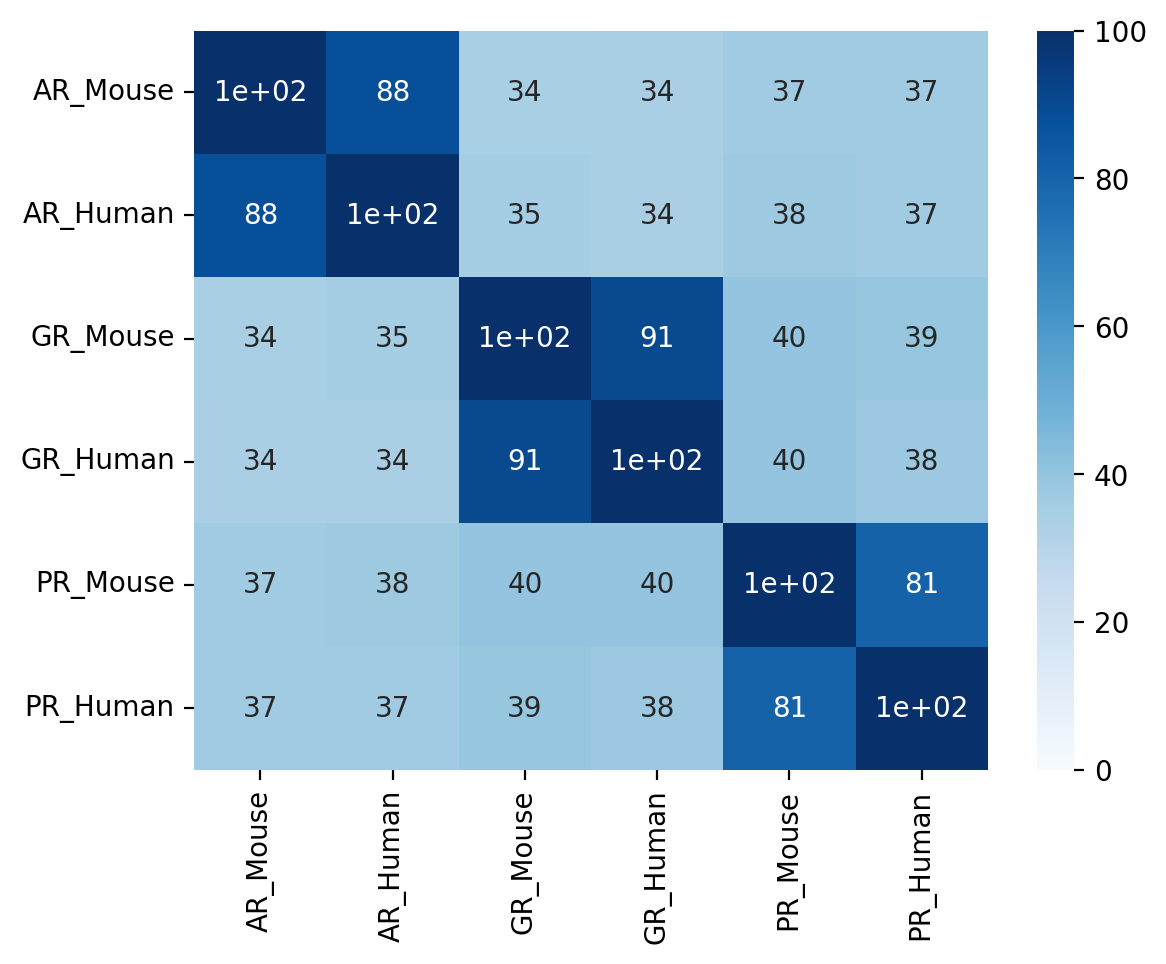

In [4]:
mat = pd.read_csv('data/auxilary/motif_similarity_matrix.csv', index_col=0)
fig, ax = plt.subplots(1)
sns.heatmap(mat, vmin=0, cmap='Blues', annot=True, ax=ax)
fig.savefig('figures/Supp/S1B.pdf')

## S1C

In [5]:

hPR = wts.filter(regex='hPR', axis=0)
mAR = wts.filter(regex='mAR', axis=0)
smad = wts.filter(regex='SMAD', axis=0)

# plot_QC(prepare_for_QC_plot(mAR, 'NR'), 'nmnumgAR', save=True, save_path='figures/Supp/S1C_1.pdf')

# plot_QC(prepare_for_QC_plot(hPR, 'NR'), 'nmnumgPR', save=True, save_path='figures/Supp/S1C_2.pdf')

# plot_QC(prepare_for_QC_plot(smad, 'SMAD'), 'nmnumgSMAD', save=True, save_path='figures/Supp/S1C_3.pdf')


## S1D/S4B 

In [6]:
s1d_s4b_meta = metadata.loc[['nmumg_hgr_wt_lig','nmumg_hgr_dlbd','nmumg_hgr_dlbd_dn400', 'nmumg_hpr_wt_lig', 'nmumg_hpr_dbd', 'nmumg_hpr_del_lbd','nmumg_mar_wt_lig', 'nmumg_mar_dbd', 'nmumg_mar_dlbd']]

In [17]:
s1d_s4b_meta = metadata.loc[['nmumg_hgr_wt_lig','nmumg_hgr_dlbd','nmumg_hgr_dlbd_dn400', 'nmumg_hpr_wt_lig', 'nmumg_hpr_dbd', 'nmumg_hpr_del_lbd','nmumg_mar_wt_lig', 'nmumg_mar_dbd', 'nmumg_mar_dlbd']]
frips = dict()
for i in s1d_s4b_meta.index:
    
    lbw = pw.open(metadata.loc[i, 'AverageBw'])
    sums = []
    for key, value in lbw.chroms().items():
        sums.append(lbw.stats(key, 0, value, 'sum', exact=True, numpy=True)[0])
    allreads = np.nansum(sums)
    
    psums = list()
    cp = pr.read_bed(metadata.loc[i, 'peaks_w_summits'])
    for k in cp.df.iloc[:, [0,1,2]].values:
        psums.append(lbw.stats(k[0], k[1], k[2], 'sum', exact=True, numpy=True)[0])
    allpreads = np.nansum(psums)
    lbw.close()

    frips[i] = (allreads, allpreads)

/home/labs/barkailab/vovam/miniconda/envs/mammal/lib/python3.11/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/miniconda/envs/mammal/lib/python3.11/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/miniconda/envs/mammal/lib/python3.11/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version 

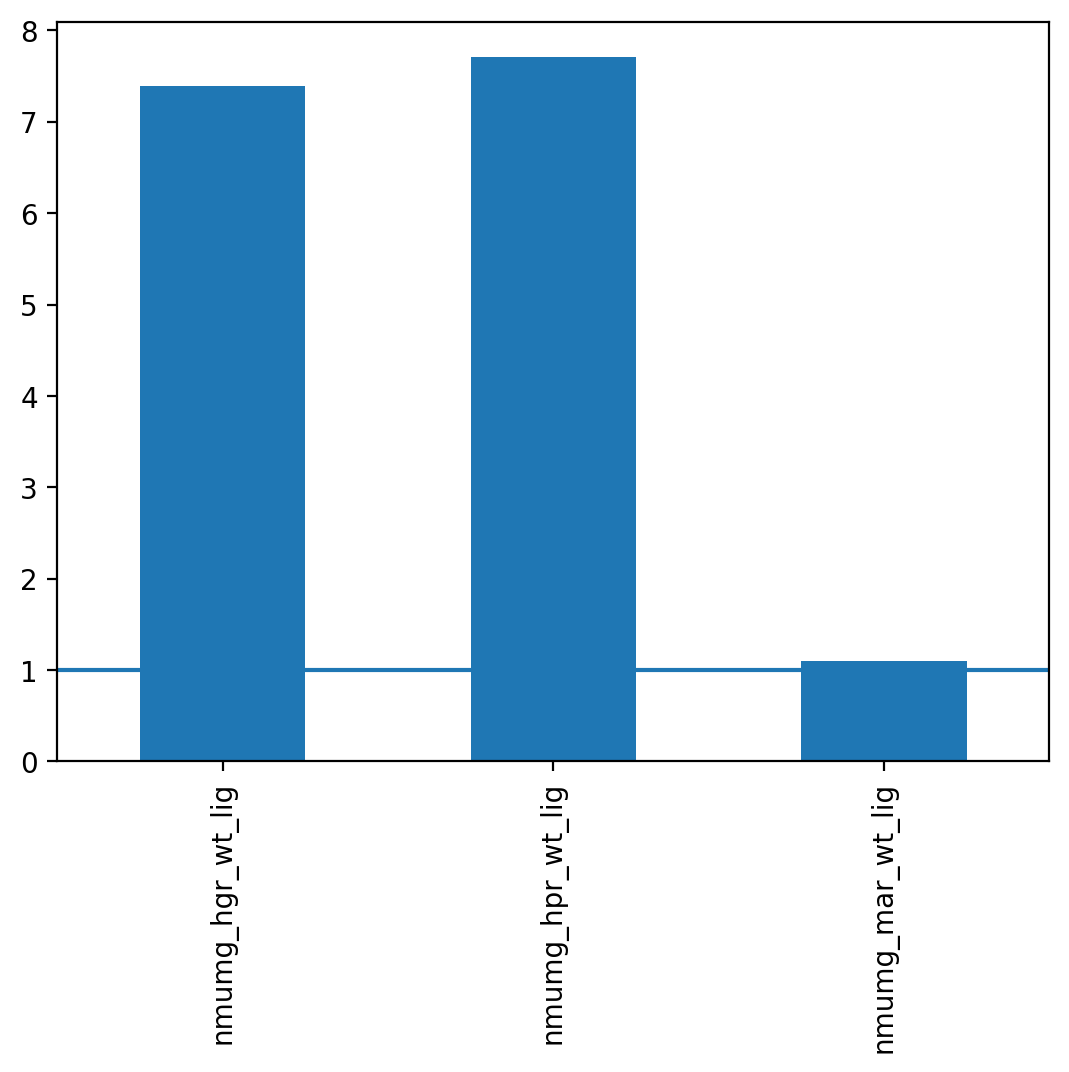

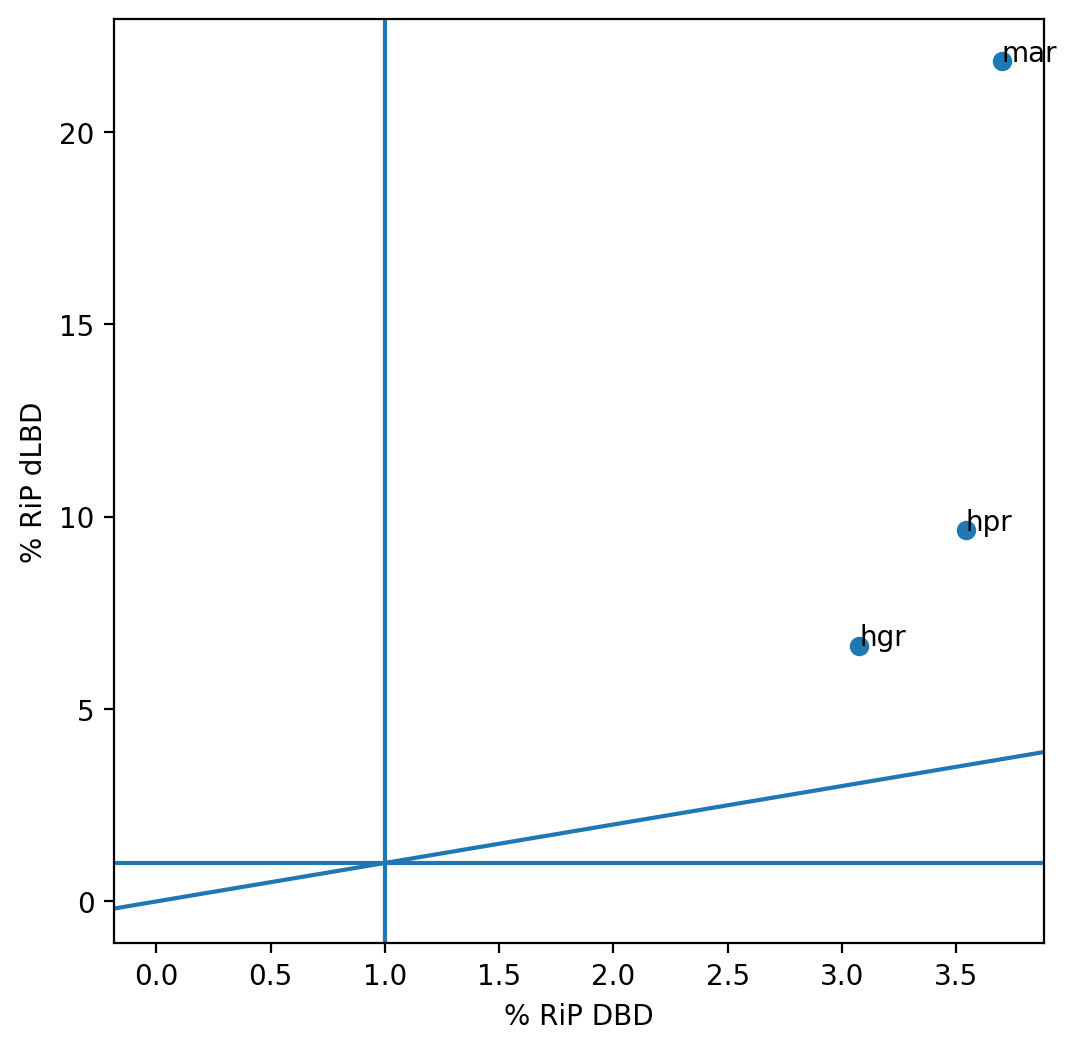

In [18]:
df = pd.DataFrame(frips, index=['allreads', 'peakreads']).T
frac = df.peakreads / df.allreads

fig, ax = plt.subplots(1)
(frac.loc[['nmumg_hgr_wt_lig', 'nmumg_hpr_wt_lig', 'nmumg_mar_wt_lig']]*100).plot.bar(ax=ax)
ax.axhline(1)
fig.savefig('figures/Supp/S1D.pdf')


fig, ax = plt.subplots(1, figsize=(6,6))
x = frac.loc[['nmumg_hgr_dlbd_dn400', 'nmumg_hpr_dbd', 'nmumg_mar_dbd']] * 100
y = frac.loc[['nmumg_hgr_dlbd', 'nmumg_hpr_del_lbd', 'nmumg_mar_dlbd',]] * 100

ax.scatter(x, y)
ax.axline((0,0), slope=1)
ax.axhline(1)
ax.axvline(1)
ax.set_xlabel('% RiP DBD')
ax.set_ylabel('% RiP dLBD')

for annx, anny in zip(x.index, y.index):
    ax.annotate(annx.split('_')[1], (x[annx], y[anny]))

fig.savefig('figures/Supp/S4B.pdf')

## S1F

/tmp/ipykernel_3434000/3340516007.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


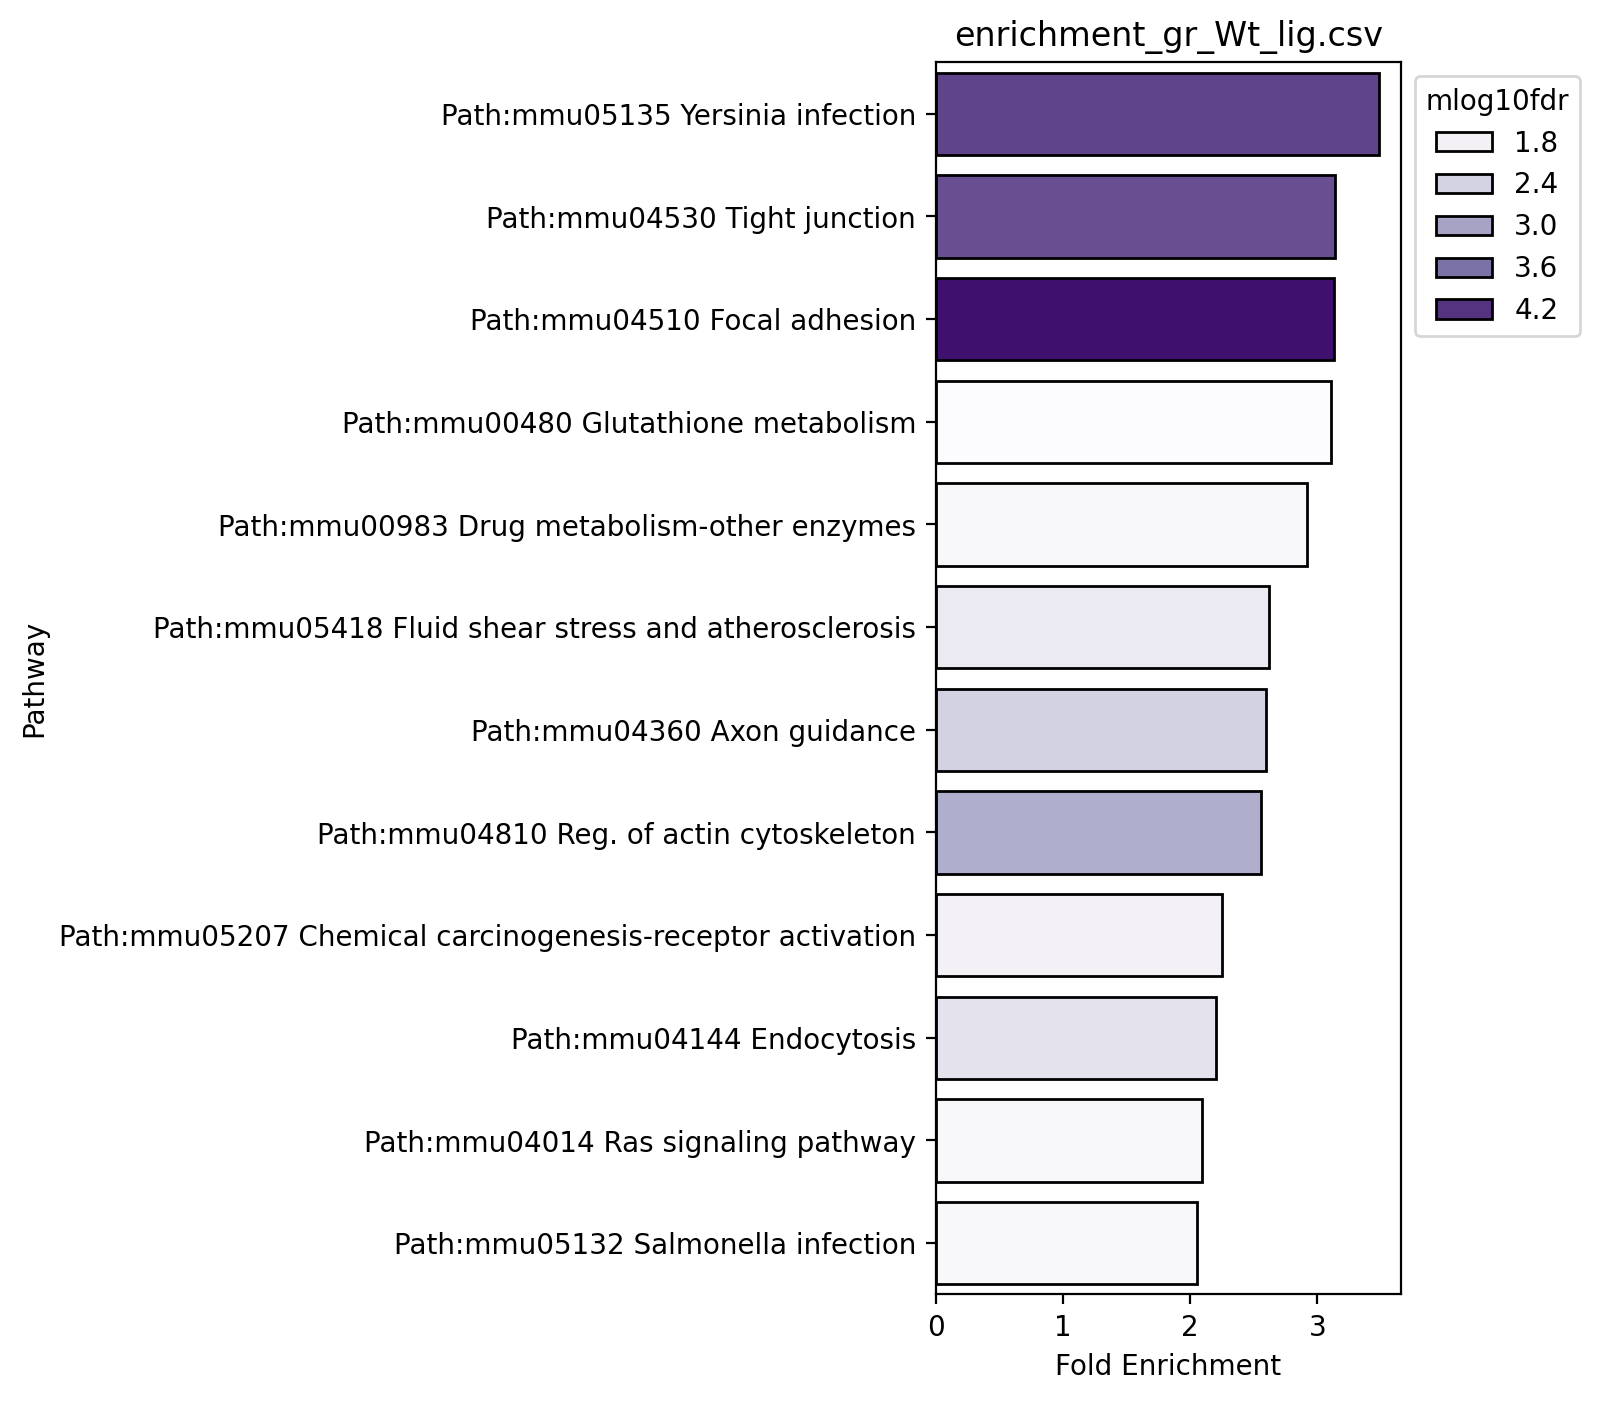

In [9]:
enrich_gos = glob.glob('data/auxilary/enrichment_gr_Wt_lig*')
dat = pd.read_csv(enrich_gos[0])
dat.loc[:, 'mlog10fdr'] = -np.log10(dat.loc[:, 'Enrichment FDR'])
fig, ax = plt.subplots(1, figsize=(3,8))
s = sns.barplot(data=dat[dat['Fold Enrichment'] > 2], x='Fold Enrichment', y='Pathway', hue='mlog10fdr', palette='Purples', ec='k', ax=ax)
sns.move_legend(s, loc='best', bbox_to_anchor=[1,1])
ax.set_title(enrich_gos[0].split('/')[-1])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
fig.savefig('figures/Supp/S1F.pdf')

# S2

## S2B

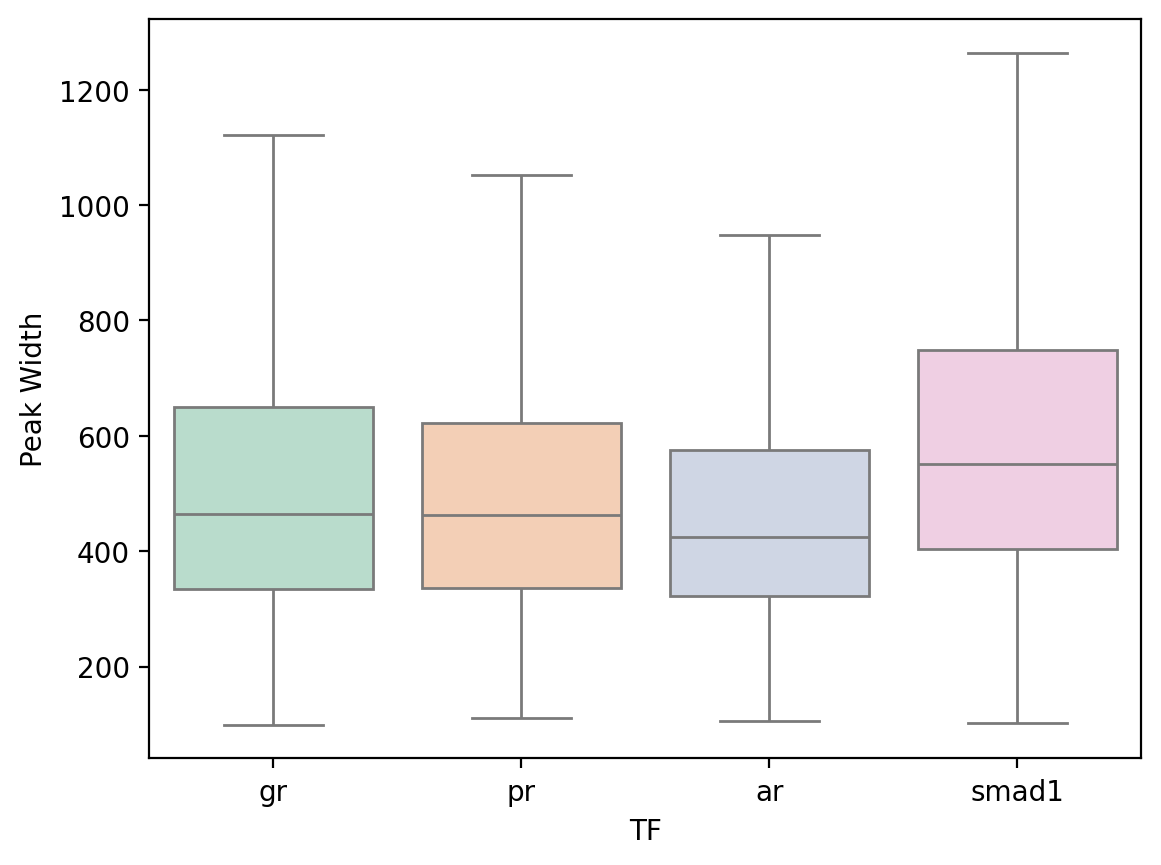

In [10]:
nmumg_peaks = metadata.filter(regex='lig|bmp', axis=0).filter(regex='nmumg', axis=0).loc[:, 'peaks_w_summits'].values
peak_len_func = lambda x: pl.read_csv(x, has_header=False, separator='\t').with_columns((pl.col('column_3') - pl.col('column_2')).alias('Width')).select('Width').to_numpy().T.squeeze()
fig, ax = plt.subplots(1)
sns.boxplot(dict(zip(['gr', 'pr', 'ar', 'smad1'], map(peak_len_func, nmumg_peaks))), showfliers=False, palette='Pastel2', ax=ax)
ax.set_xlabel('TF')
ax.set_ylabel("Peak Width")
fig.savefig('figures/Supp/S2B.pdf')

## S2C, D

In [11]:
t = metadata.filter(regex='lig|bmp', axis=0).filter(regex='nmumg', axis=0).loc[:, 'peaks_w_summits']

nmumg_fimo = sorted(glob.glob('data/combined_threshed_peaks_wsummits/output_fimo_fasta_*'))
arr = np.array(list((pd.Index(nmumg_fimo).str.split('output_fimo_fasta_').str[1].str.split('_fc10_'))))

pivoted = pd.DataFrame((arr[:,0], arr[:, 1], nmumg_fimo)).T\
.pivot(index=0, columns=1, values=2)\
.rename_axis(None, axis=1)\
.rename_axis('index', axis=0)

/home/labs/barkailab/vovam/miniconda/envs/mammal/lib/python3.11/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/miniconda/envs/mammal/lib/python3.11/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/miniconda/envs/mammal/lib/python3.11/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version 

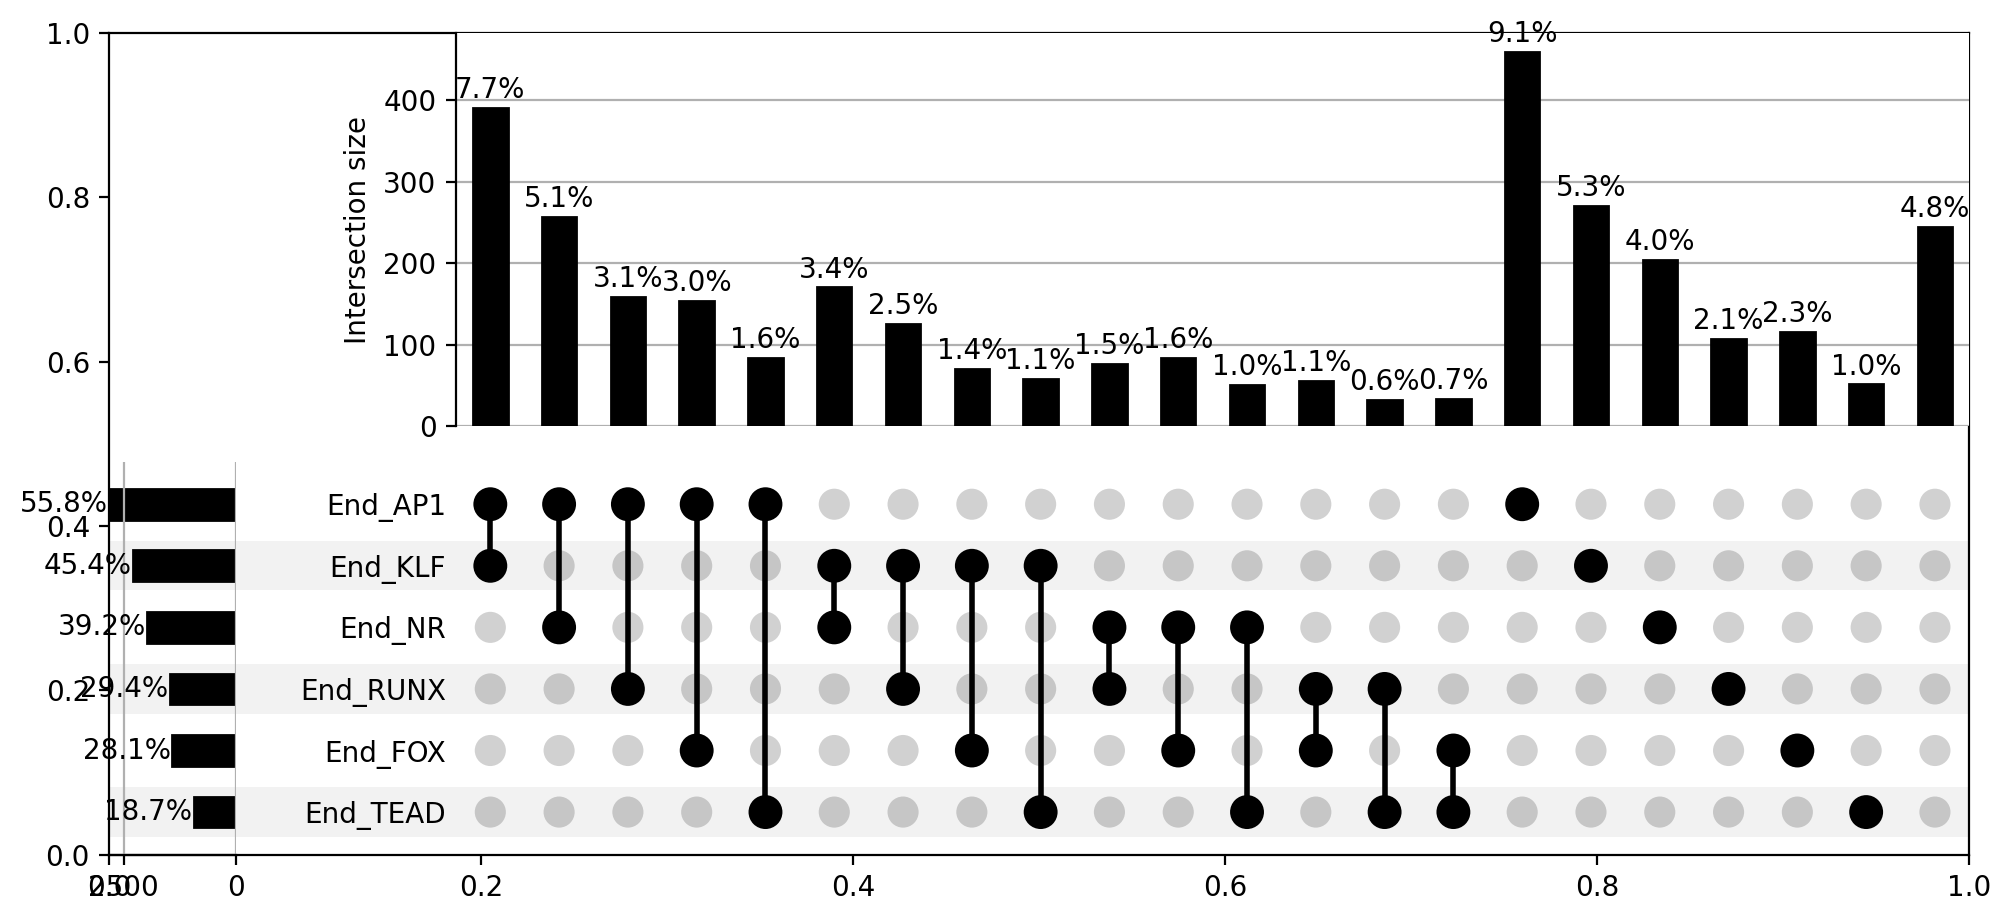

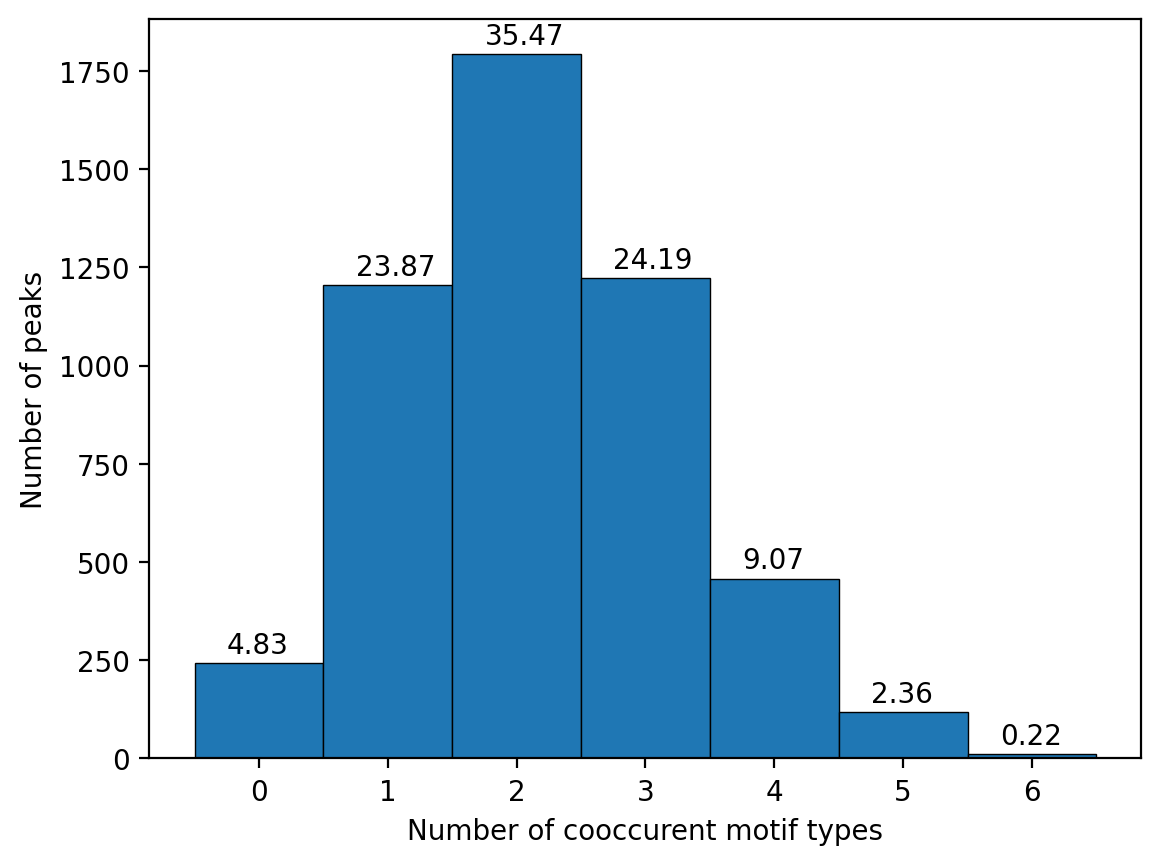

In [12]:
pr_wt_lig_fimod = pivoted.filter(regex='PR').filter(regex='nmumg_hpr_wt_lig', axis=0).drop(['PR_halfsite_mot', 'PR_CTCF_mot'], axis=1)
loaded_fimos = {key:pr.PyRanges(pr.read_gff3(os.path.join(value, 'fimo.gff')).df.loc[:, ['Chromosome', 'Start', 'End']]) for key, value in pr_wt_lig_fimod.T.squeeze().to_dict().items()}

prs = metadata.filter(regex='wt|lig', axis=0).filter(regex='nmumg', axis=0).filter(regex='pr', axis=0).drop('nmumg_hpr_wt')
peak_pr = prs.loc['nmumg_hpr_wt_lig','peaks_w_summits']
peak_pr = pr.read_bed(peak_pr).df

pr_range_peaks = pr.PyRanges(peak_pr.loc[:, ['Chromosome', 'Start', 'End']])
conc_fimo_peaks = lambda x: pr_range_peaks.join(loaded_fimos[x], how='left', suffix='_'+x.split('_')[1]).cluster().df.groupby("Cluster").agg(lambda x: list(x)[0]).iloc[:, -1:]
mot_occurences = (pd.concat(map(conc_fimo_peaks, list(loaded_fimos.keys())), axis=1)>0)*1
mot_occ_df = pd.concat([pr_range_peaks.df, mot_occurences.reset_index()], axis=1).drop("Cluster", axis=1)

binary_df = mot_occ_df.filter(regex='End_').astype(bool)

formatted_data = binary_df.groupby(binary_df.columns.tolist(), sort=False).size()
a = upsetplot.UpSet(formatted_data, show_percentages=True, max_degree=2, sort_by="-degree", sort_categories_by='-cardinality')
fig, ax= plt.subplots(1)
a.plot(fig)

fig.savefig('figures/Supp/S2C_1.pdf')

total_overlaps = pd.DataFrame(mot_occ_df.filter(regex='End_').sum(axis=1)).groupby(0).size()
total_overlaps_frac = (total_overlaps / total_overlaps.sum()) *100
fig, ax = plt.subplots(1)
ax.bar(total_overlaps.index, total_overlaps, ec='k', lw=.5, width=1)
for key, value in total_overlaps.to_dict().items():
    ax.text(key-.25, value+25, np.round(total_overlaps_frac.loc[key], 2))
    
ax.set_xlabel('Number of cooccurent motif types')
ax.set_ylabel('Number of peaks')
fig.savefig('figures/Supp/S2D_1.pdf')


/home/labs/barkailab/vovam/miniconda/envs/mammal/lib/python3.11/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/miniconda/envs/mammal/lib/python3.11/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/miniconda/envs/mammal/lib/python3.11/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version 

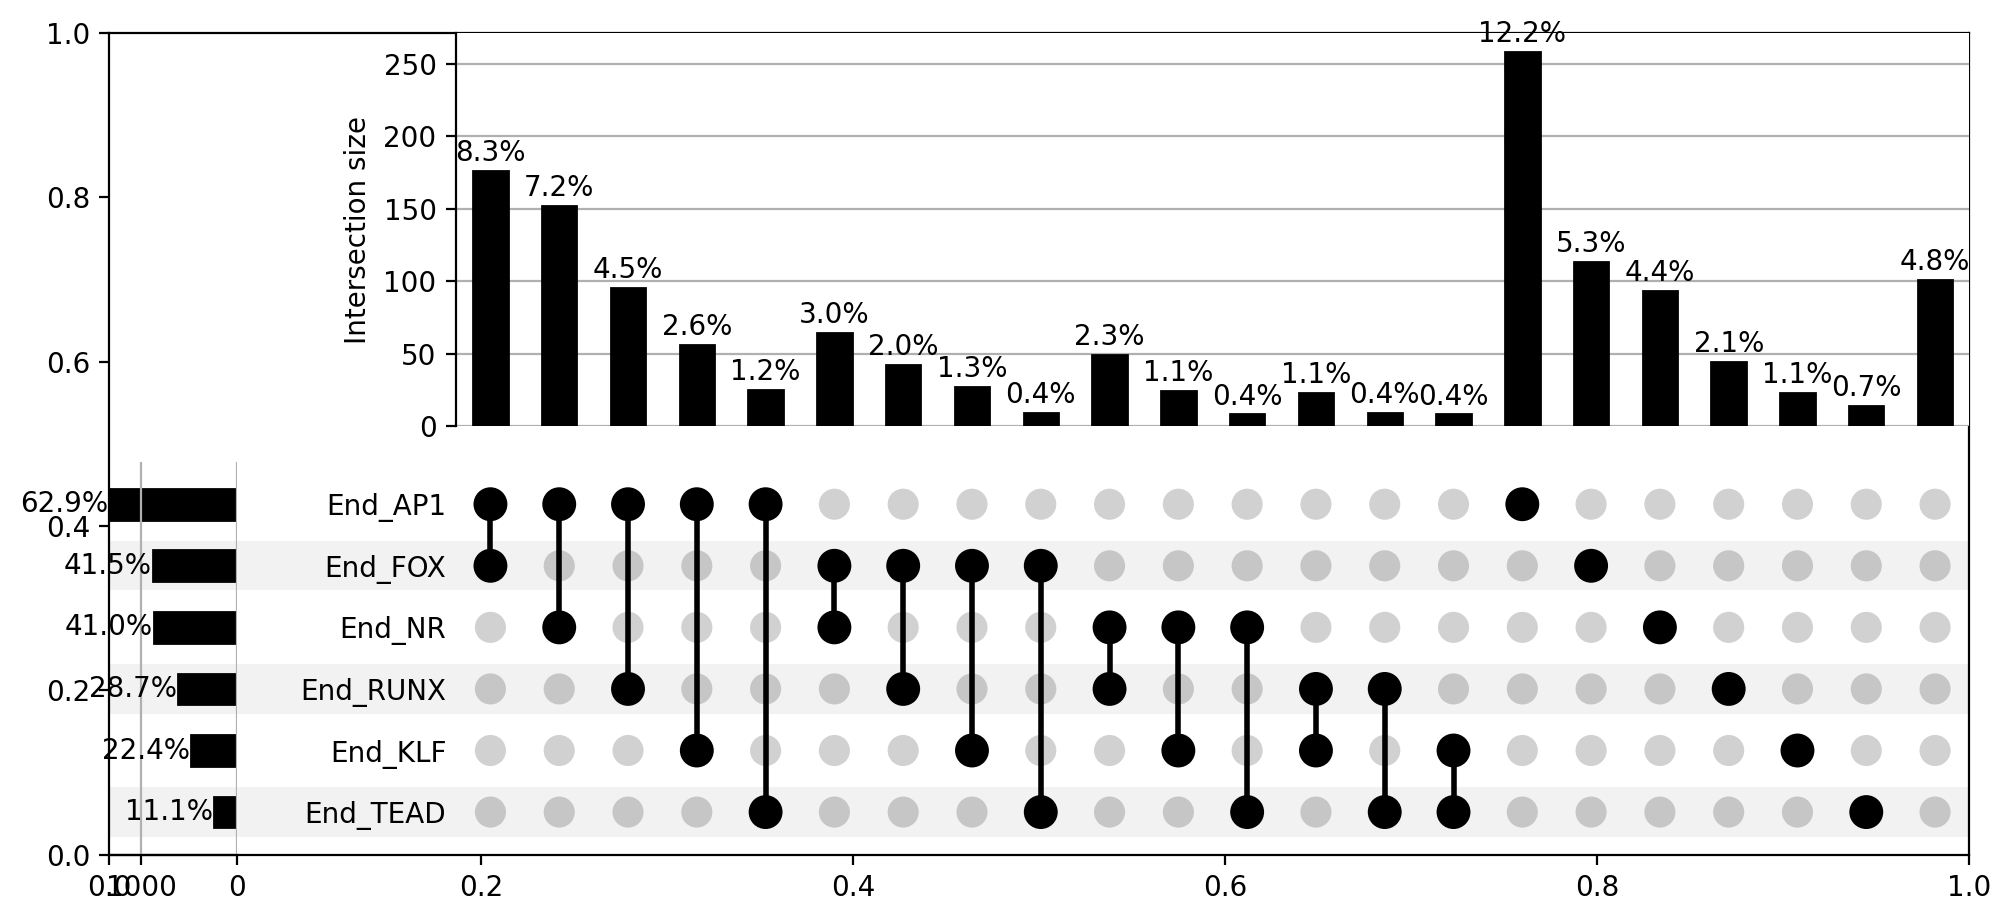

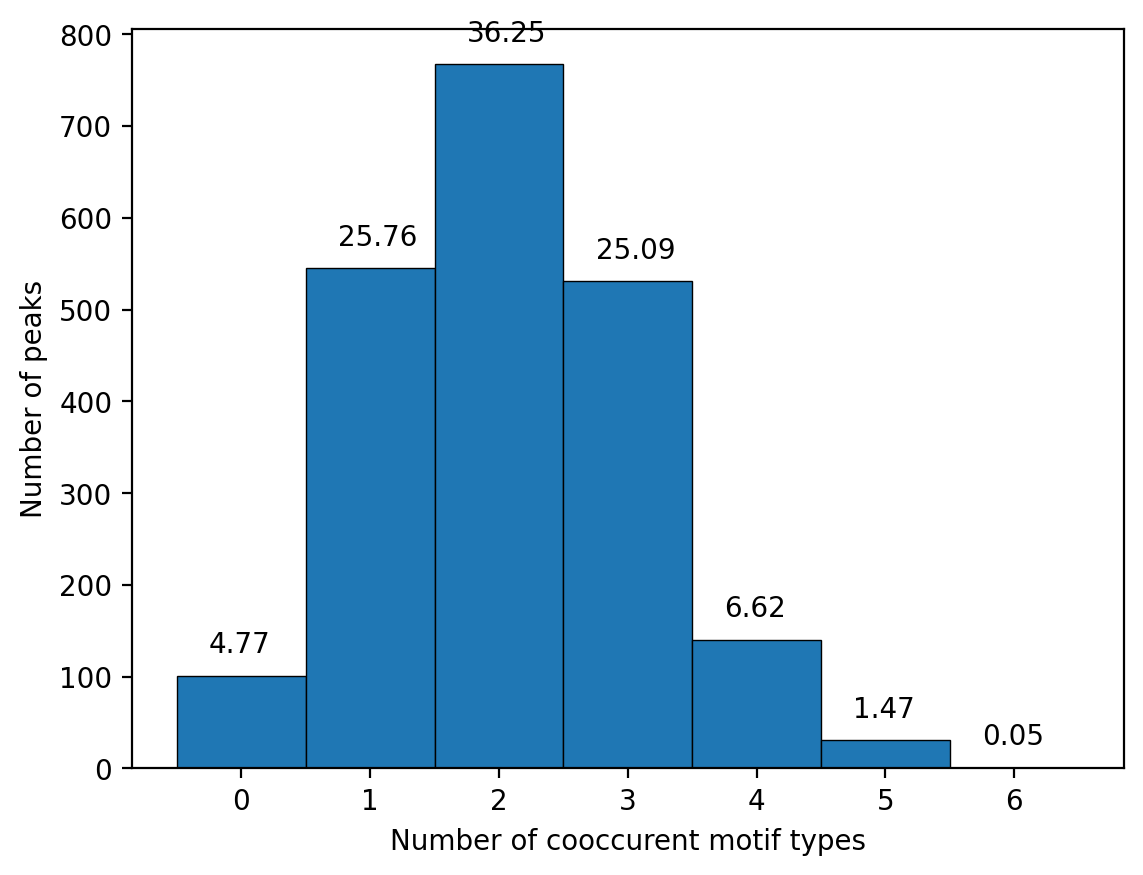

In [13]:
pr_wt_lig_fimod = pivoted.filter(regex='AR').filter(regex='nmumg_mar_wt_lig', axis=0).drop(['AR_halfsite_mot', 'AR_CTCF_mot'], axis=1)
loaded_fimos = {key:pr.PyRanges(pr.read_gff3(os.path.join(value, 'fimo.gff')).df.loc[:, ['Chromosome', 'Start', 'End']]) for key, value in pr_wt_lig_fimod.T.squeeze().to_dict().items()}

ars = metadata.filter(regex='wt|lig', axis=0).filter(regex='nmumg', axis=0).filter(regex='ar', axis=0)
peak_ar = ars.loc['nmumg_mar_wt_lig','peaks_w_summits']
peak_ar = pr.read_bed(peak_ar).df

ar_range_peaks = pr.PyRanges(peak_ar.loc[:, ['Chromosome', 'Start', 'End']])
conc_fimo_peaks = lambda x: ar_range_peaks.join(loaded_fimos[x], how='left', suffix='_'+x.split('_')[1]).cluster().df.groupby("Cluster").agg(lambda x: list(x)[0]).iloc[:, -1:]
mot_occurences = (pd.concat(map(conc_fimo_peaks, list(loaded_fimos.keys())), axis=1)>0)*1
mot_occ_df = pd.concat([ar_range_peaks.df, mot_occurences.reset_index()], axis=1).drop("Cluster", axis=1)

binary_df = mot_occ_df.filter(regex='End_').astype(bool)

formatted_data = binary_df.groupby(binary_df.columns.tolist(), sort=False).size()
a = upsetplot.UpSet(formatted_data, show_percentages=True, max_degree=2, sort_by="-degree", sort_categories_by='-cardinality')
fig, ax= plt.subplots(1)
a.plot(fig)

fig.savefig('figures/Supp/S2C_2.pdf')

total_overlaps = pd.DataFrame(mot_occ_df.filter(regex='End_').sum(axis=1)).groupby(0).size()
total_overlaps_frac = (total_overlaps / total_overlaps.sum()) *100
fig, ax = plt.subplots(1)
ax.bar(total_overlaps.index, total_overlaps, ec='k', lw=.5, width=1)
for key, value in total_overlaps.to_dict().items():
    ax.text(key-.25, value+25, np.round(total_overlaps_frac.loc[key], 2))
    
ax.set_xlabel('Number of cooccurent motif types')
ax.set_ylabel('Number of peaks')
fig.savefig('figures/Supp/S2D_2.pdf')


## S8B

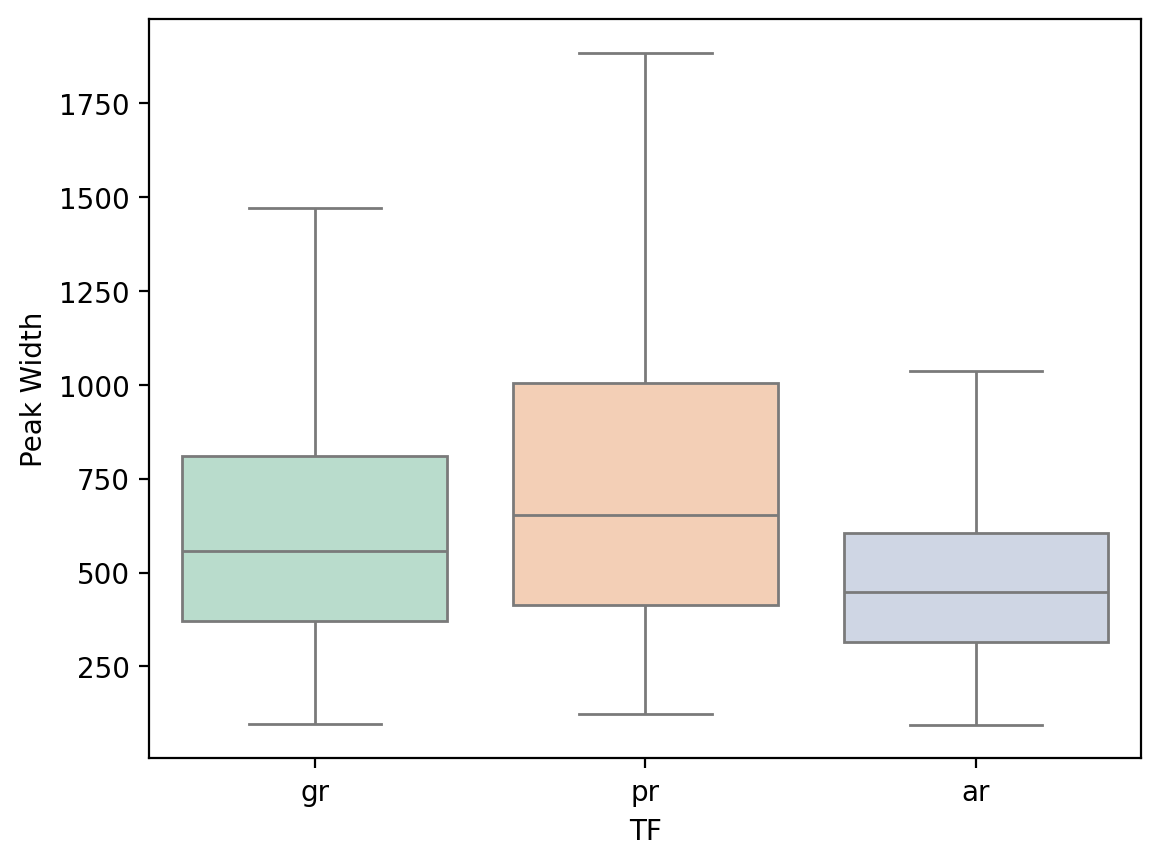

In [13]:

dbd_peaks = metadata.filter(regex='dbd', axis=0).filter(regex='nmumg', axis=0).loc[:, 'peaks_w_summits'].values


fig, ax = plt.subplots(1)
sns.boxplot(dict(zip(['gr', 'pr', 'ar', 'smad1'], map(peak_len_func, dbd_peaks))), showfliers=False, palette='Pastel2', ax=ax)
ax.set_xlabel('TF')
ax.set_ylabel("Peak Width")
fig.savefig('figures/Supp/S8B.pdf')